#    SETUP LIBS AND REPRODUCIBILITY

In [1]:
import os, json, math, random, time, csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import timm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms.functional as TF

# --- Reproducibility
SEED = 42
CHANNELS_LAST = True
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# --- Paths
TRAIN_IMG_DIR = Path("../Datasets/train/images/")
TRAIN_LBL_DIR = Path("../Datasets/train/labels/")
TEST_IMG_DIR  = Path("../Datasets/test/images/")

# Optional: where to save outputs
OUTPUT_DIR = Path("../Submission"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

/home/diyrad167/.conda/envs/test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

# HELPERS

In [2]:
def letterbox_im(im: Image.Image, max_side=1024, fill=0):
    """
    Resize keeping aspect ratio so the longer side==max_side, then pad to a square.
    No cropping -> we don't 'lose' people.
    """
    w, h = im.size
    scale = max_side / max(w, h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    im = im.resize((new_w, new_h), resample=Image.BICUBIC, reducing_gap=1.0)
    pad_w, pad_h = max_side - new_w, max_side - new_h
    # pad equally left/right, top/bottom
    pad_left  = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top   = pad_h // 2
    pad_bottom= pad_h - pad_top
    im = ImageOps.expand(im, border=(pad_left, pad_top, pad_right, pad_bottom), fill=fill)
    return im

def read_count_from_json(json_path: Path):
    with open(json_path, "r") as f:
        d = json.load(f)
    # robust: prefer `human_num` if present; else fall back to length of `points`
    if isinstance(d, dict):
        if "human_num" in d and isinstance(d["human_num"], (int, float)):
            return float(d["human_num"])
        if "points" in d and isinstance(d["points"], list):
            return float(len(d["points"]))
    raise ValueError(f"Unexpected JSON format: {json_path}")


# DATASET DEFINITIONS

In [3]:
IM_SIZE = 672   # long side after letterbox (keeps detail, fits ResNet nicely)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class CrowdCountDataset(Dataset):
    def __init__(self, img_dir: Path, lbl_dir: Path = None, train=True):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.train = train

        self.img_files = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])
        if train:
            # assume label filenames share the base name but with .json
            self.lbl_map = {p.stem: (lbl_dir / f"{p.stem}.json") for p in self.img_files}
        else:
            self.lbl_map = None

    def __len__(self): return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img = Image.open(img_path).convert("RGB")

        # keep details: bicubic + letterbox; no random crop
        img = letterbox_im(img, max_side=IM_SIZE)

        # light augmentations that don't change counts
        if self.train:
            if random.random() < 0.5:
                img = ImageOps.mirror(img)  # H-flip
            # very mild color jitter via TF is optional (kept tiny)
            if random.random() < 0.2:
                img = TF.adjust_brightness(img, 1.0 + random.uniform(-0.08, 0.08))
                img = TF.adjust_contrast(img,  1.0 + random.uniform(-0.08, 0.08))
                img = TF.adjust_saturation(img,1.0 + random.uniform(-0.08, 0.08))

        # to tensor + normalize
        x = TF.to_tensor(img)
        x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)

        if self.train:
            lbl_path = self.lbl_map[img_path.stem]
            y = read_count_from_json(lbl_path)
            y = torch.tensor([y], dtype=torch.float32)
            return x, y, img_path.name
        else:
            return x, img_path.name


# TRAIN VAL SPLIT AND DATALOADERS

In [4]:
# Build full training set (to compute counts for stratified split)
tmp_ds = CrowdCountDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, train=True)
all_counts = []
for i in range(len(tmp_ds)):
    _, y, _ = tmp_ds[i]
    all_counts.append(y.item())
all_counts = np.array(all_counts)

# stratify by bins -> more stable val MAE across count ranges
bins = np.digitize(all_counts, np.quantile(all_counts, [0.2,0.4,0.6,0.8]))

indices = np.arange(len(tmp_ds))
val_ratio = 0.1
val_size = int(len(indices)*val_ratio)
# stratified sample
val_idx = []
for b in np.unique(bins):
    b_idx = indices[bins==b]
    k = max(1, int(round(len(b_idx)*val_ratio)))
    val_idx.extend(np.random.choice(b_idx, size=k, replace=False))
val_idx = np.array(sorted(set(val_idx)))
train_idx = np.array(sorted(list(set(indices)-set(val_idx))))

# Subset datasets
from torch.utils.data import Subset
ds_tr = Subset(tmp_ds, train_idx.tolist())
ds_va = Subset(tmp_ds, val_idx.tolist())

# Dataloaders
BATCH_SIZE = 2
ACC_STEPS = 8
NUM_WORKERS = min(2, os.cpu_count() or 2)

dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

len(ds_tr), len(ds_va)

(1710, 190)

# MODEL

In [5]:
def build_swin_small_regressor(pretrained=True, freeze_to=2, use_checkpoint=True, img_size=IM_SIZE):
    backbone = timm.create_model(
        'swin_small_patch4_window7_224',   # Swin-Small backbone
        pretrained=pretrained,
        num_classes=0,          # pooled features only
        global_pool='avg',
        img_size=img_size,
        strict_img_size=False   # allow flexible H/W (like your letterboxed 672)
    )

    # Enable gradient checkpointing (saves VRAM at cost of speed)
    if use_checkpoint and hasattr(backbone, "set_grad_checkpointing"):
        backbone.set_grad_checkpointing(True)

    # Regression head: pooled features -> MLP -> scalar
    head = nn.Sequential(
        nn.LayerNorm(backbone.num_features),
        nn.Linear(backbone.num_features, 512),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(512, 1)
    )
    model = nn.Sequential(backbone, head)

    # Freeze early Swin stages (0..freeze_to-1) to stabilize and save VRAM
    try:
        layers = backbone.layers
        for li, layer in enumerate(layers):
            if li <= freeze_to - 1:
                for p in layer.parameters():
                    p.requires_grad = False
        if freeze_to > 0:
            for _, p in backbone.patch_embed.named_parameters():
                p.requires_grad = False
            if hasattr(backbone, "pos_drop"):
                for p in backbone.pos_drop.parameters():
                    p.requires_grad = False
    except Exception:
        # fallback: freeze by name
        for name, p in backbone.named_parameters():
            if any(name.startswith(k) for k in ("patch_embed", "pos_drop", "layers.0", "layers.1")):
                p.requires_grad = False

    return model

# Build and move to device
model = build_swin_small_regressor(pretrained=True, freeze_to=2, use_checkpoint=True, img_size=IM_SIZE).to(device)
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

# Loss & metric
loss_fn = nn.SmoothL1Loss(beta=2.0)  # Huber loss, robust for crowd counts
@torch.no_grad()
def mae(pred, target):
    return (pred.squeeze(1) - target.squeeze(1)).abs().mean().item()

# OPT AND SCHED

In [6]:
LR = 5e-5
WD = 5e-2   # 0.05 works well with AdamW on transformers
EPOCHS = 30
GRAD_CLIP = 1.0
WARMUP_EPOCHS = 3

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD, betas=(0.9, 0.999))

def lr_at(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch+1)/WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5*(1+math.cos(math.pi*t))

sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_at)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

/tmp/ipykernel_48915/3629945129.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


# TRAIN AND VAL LOOP

In [7]:
# OUTPUT_DIR = Path("../Submission"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR_MODEL = Path("../Models"); OUTPUT_DIR_MODEL.mkdir(parents=True, exist_ok=True)
BEST_PATH = OUTPUT_DIR_MODEL / "best_SwinSmall.pth"
best_mae, bad_epochs = float("inf"), 0
patience = 10

# collect per-epoch curves for later plotting
history = {'tr_loss': [], 'tr_mae': [], 'va_loss': [], 'va_mae': [], 'lr': []}

for epoch in range(EPOCHS):
    t0 = time.time()
    model.train()
    tr_loss = tr_mae = 0.0
    n_tr = 0
    opt.zero_grad(set_to_none=True)

    steps_in_epoch = 0
    for step, batch in enumerate(dl_tr):
        steps_in_epoch = step + 1

        x, y, _ = batch
        if CHANNELS_LAST:
            x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            pred = model(x)
            loss = loss_fn(pred, y) / ACC_STEPS   # gradient accumulation

        scaler.scale(loss).backward()

        do_step = (steps_in_epoch % ACC_STEPS == 0)
        if do_step:
            # ✅ AMP best practice: unscale before clipping
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)

        # track epoch sums (use unscaled values)
        tr_loss += (loss.item() * ACC_STEPS) * x.size(0)
        tr_mae  += (pred.detach() - y).abs().sum().item()
        n_tr    += x.size(0)

        # free references
        del x, y, pred, loss

    # If epoch ended without hitting an ACC_STEPS boundary, flush remaining grads
    if steps_in_epoch > 0 and (steps_in_epoch % ACC_STEPS != 0):
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt)
        scaler.update()
        opt.zero_grad(set_to_none=True)

    # --- Validation (lean) ---
    model.eval()
    va_loss = va_mae = 0.0
    n_va = 0
    with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        for x, y, _ in dl_va:
            if CHANNELS_LAST:
                x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            pred = model(x)
            loss = loss_fn(pred, y)
            va_loss += loss.item() * x.size(0)
            va_mae  += (pred - y).abs().sum().item()
            n_va    += x.size(0)
            del x, y, pred, loss

    # normalize to means
    tr_loss/=max(1, n_tr); tr_mae/=max(1, n_tr)
    va_loss/=max(1, n_va); va_mae/=max(1, n_va)

    # step scheduler after metrics
    sched.step()
    cur_lr = sched.get_last_lr()[0]

    # log to history
    history['tr_loss'].append(tr_loss)
    history['tr_mae'].append(tr_mae)
    history['va_loss'].append(va_loss)
    history['va_mae'].append(va_mae)
    history['lr'].append(cur_lr)

    print(f"Epoch: {epoch+1:02d}/{EPOCHS} | "
          f"train loss: {tr_loss:.4f} MAE: {tr_mae:.2f} | "
          f"val loss: {va_loss:.4f} MAE: {va_mae:.2f} | lr: {cur_lr:.2e} | "
          f"Training time: {time.time()-t0:.2f}s")

    # Early stopping by val MAE
    if va_mae < best_mae - 1e-6:
        best_mae, bad_epochs = va_mae, 0
        torch.save({"model": model.state_dict()}, BEST_PATH)
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            # don't break history saving; fallthrough to persist
            break

    # trim once per epoch (safer & faster than per-iteration)
    torch.cuda.empty_cache()

# persist history for later cells
# OUTPUT_DIR = Path("../Submission"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
JSON_OUTPUT_HIST_DIR = Path("../JSON-history"); JSON_OUTPUT_HIST_DIR.mkdir(parents=True, exist_ok=True)
with open(JSON_OUTPUT_HIST_DIR / "history.json", "w") as f:
    json.dump(history, f)

print("Best val MAE:", best_mae)
print("Saved best model to:", BEST_PATH)
print("Saved history to:", JSON_OUTPUT_HIST_DIR / "history.json")

/tmp/ipykernel_48915/716328630.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/home/diyrad167/.conda/envs/test/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/diyrad167/.conda/envs/test/lib/python3.10/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/tmp/ipykernel_48915/716328630.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is d

Epoch: 01/25 | train loss: 133.4561 MAE: 134.42 | val loss: 117.1079 MAE: 118.07 | lr: 3.33e-05 | Training time: 315.79s
Epoch: 02/25 | train loss: 125.5592 MAE: 126.48 | val loss: 108.4728 MAE: 109.36 | lr: 5.00e-05 | Training time: 318.67s
Epoch: 03/25 | train loss: 116.7373 MAE: 117.65 | val loss: 98.8137 MAE: 99.69 | lr: 5.00e-05 | Training time: 318.99s
Epoch: 04/25 | train loss: 106.7159 MAE: 107.60 | val loss: 88.8599 MAE: 89.72 | lr: 4.97e-05 | Training time: 318.67s
Epoch: 05/25 | train loss: 98.3212 MAE: 99.23 | val loss: 80.9214 MAE: 81.82 | lr: 4.90e-05 | Training time: 319.14s
Epoch: 06/25 | train loss: 89.9152 MAE: 90.80 | val loss: 72.6260 MAE: 73.50 | lr: 4.77e-05 | Training time: 318.70s
Epoch: 07/25 | train loss: 83.2870 MAE: 84.18 | val loss: 68.8474 MAE: 69.72 | lr: 4.60e-05 | Training time: 319.55s
Epoch: 08/25 | train loss: 78.4736 MAE: 79.37 | val loss: 61.1485 MAE: 61.98 | lr: 4.39e-05 | Training time: 319.77s
Epoch: 09/25 | train loss: 73.2921 MAE: 74.16 | val 

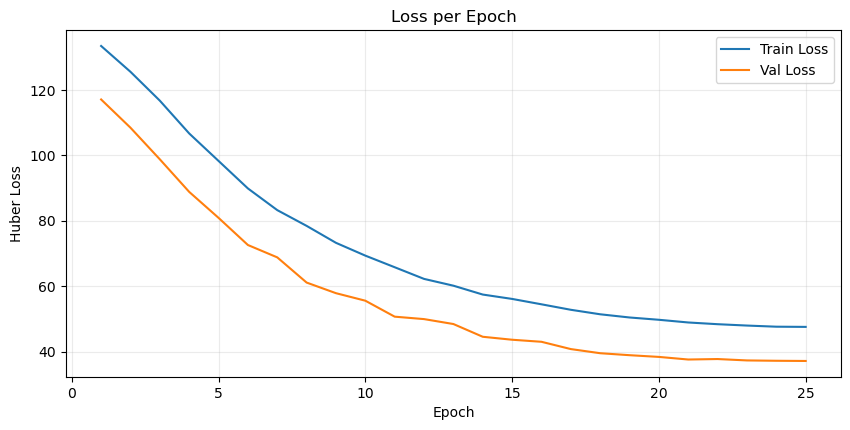

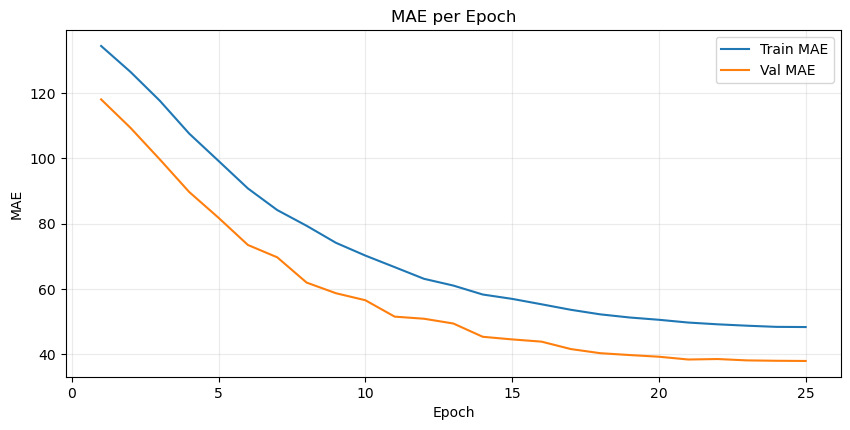

In [8]:
epochs = range(1, len(history['tr_loss'])+1)

plt.figure(figsize=(10,4.5))
plt.plot(epochs, history['tr_loss'], label='Train Loss')
plt.plot(epochs, history['va_loss'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.title('Loss per Epoch'); plt.grid(True, alpha=.25); plt.legend()
plt.show()

plt.figure(figsize=(10,4.5))
plt.plot(epochs, history['tr_mae'], label='Train MAE')
plt.plot(epochs, history['va_mae'], label='Val MAE')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.title('MAE per Epoch'); plt.grid(True, alpha=.25); plt.legend()
plt.show()

/tmp/ipykernel_48915/2956748731.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


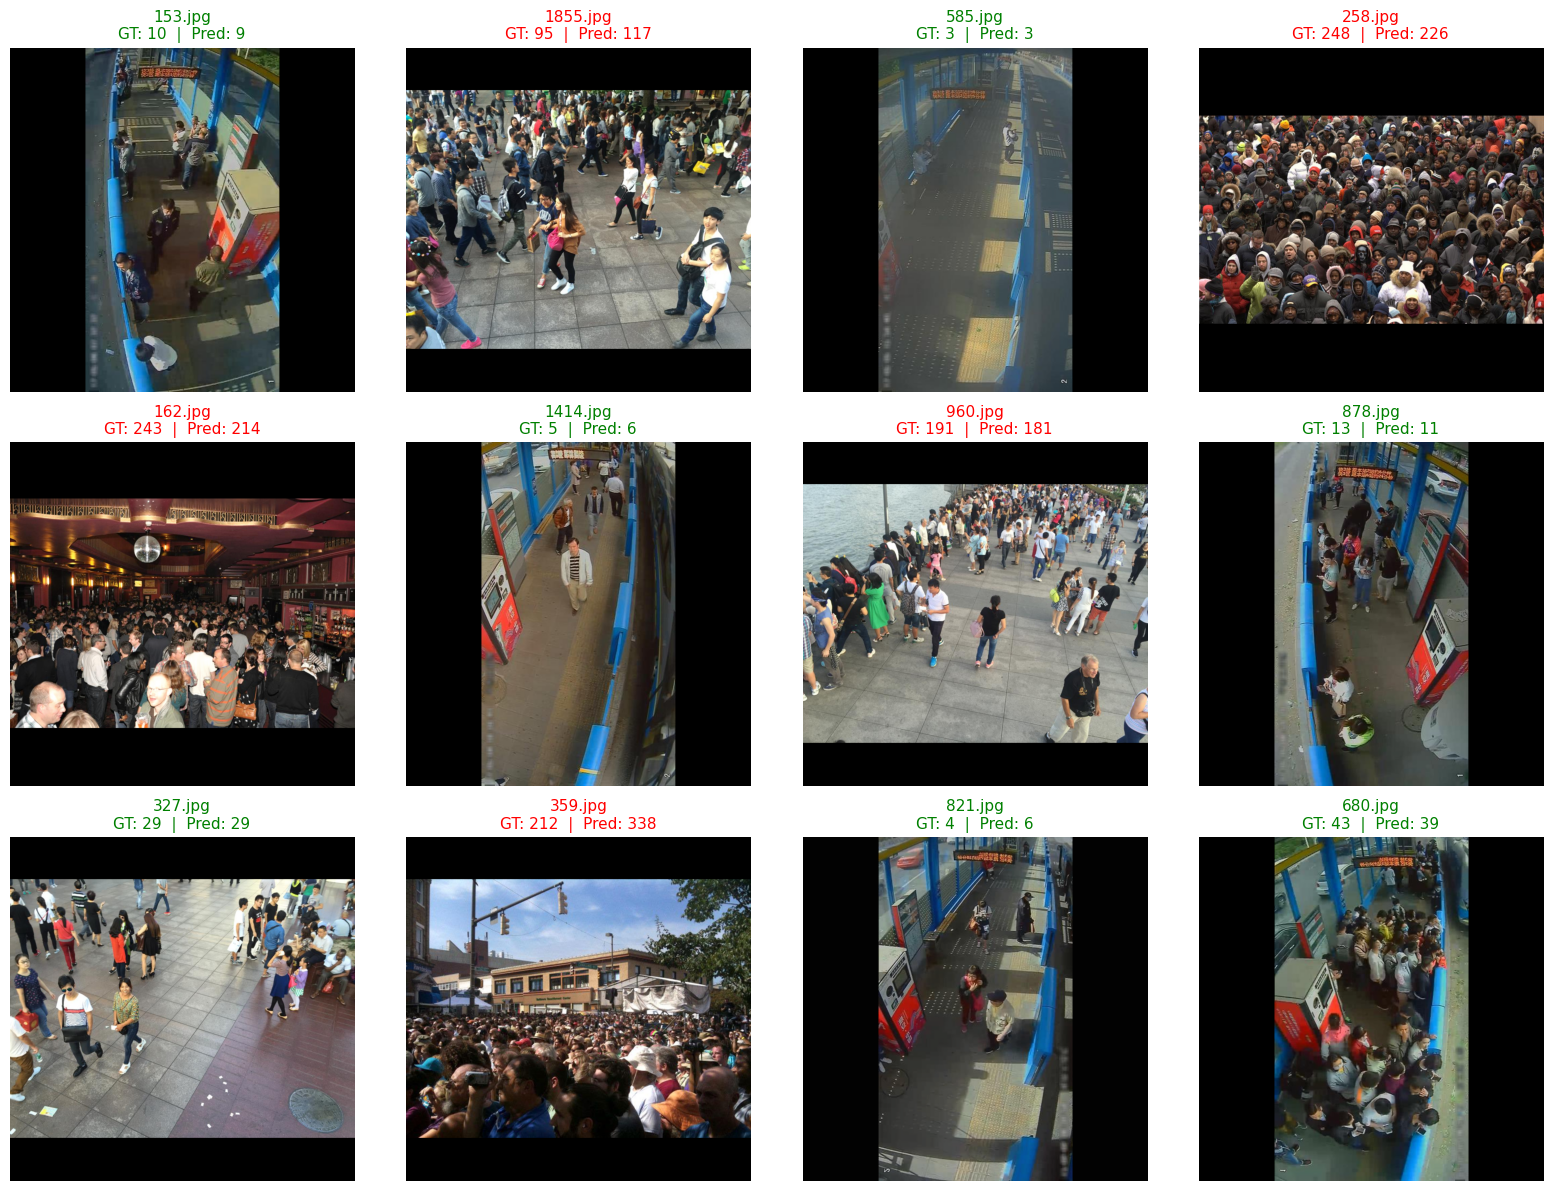

In [9]:
model.eval()

# --- helpers
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)

def denorm(img_t: torch.Tensor):
    """img_t: (3,H,W) normalized tensor on any device -> (H,W,3) numpy [0,1]"""
    if img_t.device != IMAGENET_MEAN.device:
        mean, std = IMAGENET_MEAN.cpu(), IMAGENET_STD.cpu()
    else:
        mean, std = IMAGENET_MEAN, IMAGENET_STD
    x = img_t * std + mean
    x = x.clamp(0,1).permute(1,2,0).detach().cpu().numpy()
    return x

def good_color(pred, gt):
    # "close" if absolute error <= max(5 people, 5% of GT)
    thr = max(5.0, 0.05 * float(gt))
    return 'green' if abs(float(pred) - float(gt)) <= thr else 'red'

# --- pick 12 random indices from the validation subset
NROWS, NCOLS = 3, 4
nsamples = NROWS * NCOLS
val_indices = list(range(len(ds_va)))
random.shuffle(val_indices)
val_indices = val_indices[:nsamples]

# --- run prediction in small batches (VRAM-friendly)
xs, gts, names = [], [], []
for i in val_indices:
    x, y, name = ds_va[i]  # ds_va is a Subset of the training dataset
    xs.append(x.unsqueeze(0))
    gts.append(float(y.item()))
    names.append(name)

# batch predict
with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    # cat might be large; do micro-batches
    preds = []
    micro = 4
    for s in range(0, len(xs), micro):
        bx = torch.cat(xs[s:s+micro], dim=0)
        if CHANNELS_LAST:
            bx = bx.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            bx = bx.to(device, non_blocking=True)
        by = model(bx).squeeze(1).float().detach().cpu().numpy()
        preds.extend(by.tolist())
preds = [max(0.0, p) for p in preds]  # clip to non-negative

# --- plot grid
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, 12))
axes = axes.flatten()

for ax, x, gt, pr, name in zip(axes, xs, gts, preds, names):
    # plt.title("Restnet 34 LR 0.003 WD 0.0001 AdamW")
    img = denorm(x.squeeze(0).to(device if next(model.parameters()).is_cuda else 'cpu'))
    ax.imshow(img)
    ax.axis('off')
    color = good_color(pr, gt)
    ax.set_title(f"{name}\nGT: {int(round(gt))}  |  Pred: {int(round(pr))}", color=color, fontsize=11)

plt.tight_layout()
plt.show()


# LOAD BEST AND SANITY CHECK ON VAL

In [10]:
ckpt = torch.load(BEST_PATH, map_location="cpu")
model.load_state_dict(ckpt["model"])
model.to(device)
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)
model.eval()

# 1) Build a *serial* (single-process) val loader to avoid multiprocessing issues
#    We reuse ds_va (Subset), but disable workers and pinning for this quick check.
va_loader_clean = DataLoader(
    ds_va, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False, drop_last=False
)

# 2) Optional: clear and sync before/after to flush any async CUDA error
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# 3) Run evaluation with the same memory_format you used in training
va_mae, n_va = 0.0, 0
with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    for x, y, _ in va_loader_clean:
        if CHANNELS_LAST:
            x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        pred = model(x)
        va_mae += (pred - y).abs().sum().item()
        n_va   += x.size(0)

# 4) Final sync + print
if torch.cuda.is_available():
    torch.cuda.synchronize()

print(f"Validation MAE: {va_mae / max(1, n_va):.2f}")


/tmp/ipykernel_48915/2645343910.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Validation MAE: 37.87


# TEST DATASET AND PRED

In [11]:
# 0) Safety checks: input size matches what Swin expects (multiple of 28)
assert IM_SIZE % 28 == 0, f"IM_SIZE={IM_SIZE} must be divisible by 28 for Swin windowing."

# 1) Rebuild a *serial* test loader (no workers) to avoid CUDA multiprocessing issues
class CrowdTestDataset(Dataset):
    def __init__(self, img_dir: Path):
        self.imgs = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        p = self.imgs[idx]
        im = Image.open(p).convert("RGB")
        im = letterbox_im(im, max_side=IM_SIZE)  # Same preprocessing as train/val
        x = TF.to_tensor(im)
        x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)
        return x, p.name

ds_te = CrowdTestDataset(TEST_IMG_DIR)

# Smaller batch + single-process loader tends to be the most stable on tight VRAM
BATCH_SIZE_TEST = 2
dl_te_clean = DataLoader(
    ds_te, batch_size=BATCH_SIZE_TEST, shuffle=False,
    num_workers=0, pin_memory=False, drop_last=False
)

# 2) Ensure model is on device and memory_format matches training
model.to(device)
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)
model.eval()

# 3) Extra hygiene around CUDA state
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

pred_rows = []
err = None

try:
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        for x, names in dl_te_clean:
            if CHANNELS_LAST:
                x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                x = x.to(device, non_blocking=True)

            yhat = model(x).squeeze(1).float().detach().cpu().numpy()
            yhat = np.clip(yhat, 0, None)  # counts >= 0

            for name, pred in zip(names, yhat):
                pred_rows.append((name, float(pred)))

    if torch.cuda.is_available():
        torch.cuda.synchronize()

except RuntimeError as e:
    err = e

if err is not None:
    # If we land here, the CUDA context was likely poisoned earlier.
    # The only guaranteed remedy is a kernel/runtime restart.
    raise RuntimeError(
        "CUDA evaluation failed (likely due to a prior device-side error). "
        "Please restart the kernel and re-run with the fixed Swin settings "
        "(IM_SIZE multiple of 28 and strict_img_size=False)."
    ) from err

# 4) Write submission (preserve sample order if provided)
sample_csv = Path("../Submission/sub_swinSmall_25ep_adamw_wd005_lr5e5.csv")  # adjust if needed
if sample_csv.exists():
    import pandas as pd
    sub = pd.read_csv(sample_csv)
    key, outcol = sub.columns[:2]
    pred_map = {k: v for k, v in pred_rows}
    sub[outcol] = sub[key].map(lambda k: round(pred_map.get(k, 0.0)))
    out_path = OUTPUT_DIR / "sub_swinSmall_25ep_adamw_wd005_lr5e5.csv"
    sub.to_csv(out_path, index=False)
else:
    out_path = OUTPUT_DIR / "sub_swinSmall_25ep_adamw_wd005_lr5e5.csv"
    with open(out_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["image_id", "count"])
        for k, v in pred_rows:
            w.writerow([k, round(v)])

print("Wrote:", out_path)


/tmp/ipykernel_48915/2743345443.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Wrote: ../Submission/sub_swinSmall_25ep_adamw_wd005_lr5e5.csv
